# Options Pricing — Black-Scholes sur TSMC (TSM)

Pricing Black-Scholes, extraction de la volatilité implicite par mes propres solveurs, et analyse du smile sur la chaîne d'options TSMC en direct.

> ⚠️ **Mode Yahoo : à lancer pendant la séance US (15h30–22h, heure de Paris).** Hors séance, Yahoo renvoie `bid = ask = 0` et des vols implicites inexploitables. Sinon, utiliser le mode CSV avec un snapshot (Bloomberg, Barchart…).

**Stack :** Python · numpy · pandas · scipy · matplotlib · yfinance

## 1. Pricing Black-Scholes

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm
from datetime import datetime
import yfinance as yf

TICKER = "TSM"
q = 0.0     # prochain détachement le 10/12/26, après l'échéance du 20/11 → aucun dividende pendant la vie de l'option (rendement annuel : 0,81 %)

def black_scholes(S, K, r, q, sigma, T, option_type="call"):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def bs_vega(S, K, r, q, sigma, T):
    if T <= 0 or sigma <= 0: return 1e-10
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

# Vérification — parité call-put : C - P = S·e^(-qT) - K·e^(-rT)
S_t, K_t, r_t, q_t, sig_t, T_t = 180.0, 175.0, 0.04, 0.012, 0.25, 0.5
call_p = black_scholes(S_t, K_t, r_t, q_t, sig_t, T_t, "call")
put_p  = black_scholes(S_t, K_t, r_t, q_t, sig_t, T_t, "put")
lhs, rhs = call_p - put_p, S_t * np.exp(-q_t * T_t) - K_t * np.exp(-r_t * T_t)
print(f"Call = {call_p:.4f} $  |  Put = {put_p:.4f} $")
print(f"Parité call-put : {lhs:.6f} = {rhs:.6f}  {'✓' if abs(lhs-rhs)<1e-8 else '✗'}")

Call = 16.3845 $  |  Put = 8.9960 $
Parité call-put : 7.388466 = 7.388466  ✓


## 2. Volatilité implicite — mes solveurs

Newton-Raphson codé à la main, avec repli sur Brent (scipy) si Newton ne converge pas (vega trop faible sur les options loin de la monnaie).

In [2]:
def implied_vol_newton(price, S, K, r, q, T, option_type="call", sigma0=0.3, tol=1e-8, max_iter=100):
    sigma = sigma0
    for _ in range(max_iter):
        diff = black_scholes(S, K, r, q, sigma, T, option_type) - price
        if abs(diff) < tol: return sigma
        vega = bs_vega(S, K, r, q, sigma, T)
        if vega < 1e-8: return np.nan
        sigma -= diff / vega
        if sigma <= 0: sigma = 1e-4
    return np.nan

def implied_vol_scipy(price, S, K, r, q, T, option_type="call", method="brentq"):
    f = lambda s: black_scholes(S, K, r, q, s, T, option_type) - price
    try:
        if method in ("brentq", "bisect", "toms748"):
            return getattr(optimize, method)(f, 1e-4, 5.0, xtol=1e-10)
        return optimize.newton(f, 0.3, fprime=lambda s: bs_vega(S, K, r, q, s, T), tol=1e-10)
    except Exception:
        return np.nan

def implied_vol(price, S, K, r, q, T, option_type="call"):
    """Newton en priorité, Brent en secours. NaN si le prix viole les bornes d'arbitrage."""
    intrinsic = black_scholes(S, K, r, q, 1e-6, T, option_type)
    if not np.isfinite(price) or price <= intrinsic + 1e-6:
        return np.nan
    iv = implied_vol_newton(price, S, K, r, q, T, option_type)
    return iv if np.isfinite(iv) else implied_vol_scipy(price, S, K, r, q, T, option_type, "brentq")

print(f"Cible : σ = {sig_t}\n")
for name, iv in {
    "Newton (manuel)": implied_vol_newton(call_p, S_t, K_t, r_t, q_t, T_t),
    **{f"scipy.{m}": implied_vol_scipy(call_p, S_t, K_t, r_t, q_t, T_t, method=m)
       for m in ["brentq", "bisect", "newton", "toms748"]}
}.items():
    print(f"  {name:<18} → {iv:.8f}  {'✓' if abs(iv - sig_t) < 1e-6 else '✗'}")

Cible : σ = 0.25

  Newton (manuel)    → 0.25000000  ✓
  scipy.brentq       → 0.25000000  ✓
  scipy.bisect       → 0.25000000  ✓
  scipy.newton       → 0.25000000  ✓
  scipy.toms748      → 0.25000000  ✓


## 3. Données de marché

Deux sources possibles :
- **`"yahoo"`** : chaîne en direct via `yfinance`. À lancer **pendant la séance US (15h30–22h, heure de Paris)**.
- **`"csv"`** : snapshot saisi à la main (Bloomberg `OMON`, Barchart, Nasdaq…). Colonnes : `expiry, type, strike, bid, ask, openInterest` (+ `iv_source` facultatif, l'IV affichée par la source, pour comparaison). Renseigner le spot, la date et le taux **du moment du snapshot**.

**Échéance** retenue : entre 25 et 70 jours. Plus court, l'IV devient instable ; plus long, moins de liquidité.

In [3]:
SOURCE = "csv"                  # "csv" = snapshot figé du 22/09/2026 | "yahoo" = données en direct

# --- Paramètres du mode CSV (à remplir avec les valeurs du snapshot) ---
CSV_PATH        = "chain_tsm.csv"
S_MANUAL        = 452.00          # clôture TSM du 22/09/2026 (Barchart)
DATE_MANUAL     = "2026-09-22"    # date du snapshot
R_MANUAL        = 0.0409          # T-bill 2 mois au 22/09/2026 (US Treasury), maturité la plus proche des 59 jours
VOL_HIST_MANUAL = 0.2782          # vol historique affichée par Barchart au 22/09/2026
SOURCE_LABEL    = "Barchart, clôture du 22/09/2026"

if SOURCE == "yahoo":
    ticker = yf.Ticker(TICKER)
    S = float(ticker.history(period="1d")["Close"].iloc[-1])
    try:
        r = float(yf.Ticker("^IRX").history(period="5d")["Close"].dropna().iloc[-1]) / 100
    except Exception:
        r = 0.04; print("⚠️ ^IRX indisponible, r fixé à 4 % par défaut")
    today = datetime.now()
    expirations = list(ticker.options)
    def get_chain(exp):
        ch = ticker.option_chain(exp)
        return ch.calls.copy(), ch.puts.copy()
    SOURCE_LABEL = "Yahoo Finance, temps réel"
    IV_LABEL = "IV Yahoo"
else:
    raw = pd.read_csv(CSV_PATH)
    raw["type"] = raw["type"].str.lower().str.strip()
    raw["expiry"] = pd.to_datetime(raw["expiry"]).dt.strftime("%Y-%m-%d")
    if "openInterest" not in raw: raw["openInterest"] = np.nan
    raw["impliedVolatility"] = raw["iv_source"] / 100 if "iv_source" in raw else np.nan
    IV_LABEL = "IV Barchart"
    assert S_MANUAL > 0, "Renseigne S_MANUAL (spot au moment du snapshot)"
    S, r, today = S_MANUAL, R_MANUAL, datetime.strptime(DATE_MANUAL, "%Y-%m-%d")
    expirations = sorted(raw["expiry"].unique())
    def get_chain(exp):
        d = raw[raw["expiry"] == exp]
        return (d[d["type"] == "call"].reset_index(drop=True),
                d[d["type"] == "put"].reset_index(drop=True))

days_to = lambda e: (datetime.strptime(e, "%Y-%m-%d") - today).days
candidates = [e for e in expirations if 25 <= days_to(e) <= 70]
exp_date = candidates[0] if candidates else min(expirations, key=lambda e: abs(days_to(e) - 45))
T = max(days_to(exp_date), 1) / 365.0
calls_raw, puts_raw = get_chain(exp_date)

quoted = ((calls_raw["bid"] > 0) & (calls_raw["ask"] > 0)).mean()
print(f"Source : {SOURCE_LABEL}  |  date : {today:%Y-%m-%d}")
print(f"Spot {TICKER} : {S:.2f} $  |  r : {r:.2%}  |  q : {q:.2%}")
print(f"Échéance : {exp_date} ({days_to(exp_date)} jours)  |  Calls : {len(calls_raw)}  |  Puts : {len(puts_raw)}")
print(f"Options avec bid/ask : {quoted:.0%}")
if quoted < 0.5:
    raise RuntimeError("Bid/ask absents : marché fermé (mode yahoo) ou colonnes vides (mode csv).")

Source : Barchart, clôture du 22/09/2026  |  date : 2026-09-22
Spot TSM : 452.00 $  |  r : 4.09%  |  q : 0.00%
Échéance : 2026-11-20 (59 jours)  |  Calls : 20  |  Puts : 20
Options avec bid/ask : 100%


## 4. Sélection des options liquides

- **Bid et ask > 0** : on ne garde que ce qui est réellement coté.
- **Prix = mid (bid+ask)/2**, plutôt que `lastPrice` qui peut dater de plusieurs heures.
- **Spread relatif ≤ 25 %** du mid : au-delà, le prix n'est pas fiable.
- **Open interest ≥ 50** et **moneyness K/S entre 0,80 et 1,20**.
- **Options OTM uniquement** pour le smile (puts sous le spot, calls au-dessus) : ce sont les plus liquides, c'est la convention des desks.

In [4]:
def prepare(df, S, T, r, q, option_type, min_oi=50, max_spread=0.25, k_range=(0.80, 1.20)):
    df = df.copy()
    df["openInterest"] = df["openInterest"].fillna(min_oi)  # si OI non saisi, on ne filtre pas dessus
    df["mid"] = (df["bid"] + df["ask"]) / 2
    df["spread_rel"] = (df["ask"] - df["bid"]) / df["mid"]
    df["K/S"] = df["strike"] / S
    mask = ((df["bid"] > 0) & (df["ask"] > 0) & (df["spread_rel"] <= max_spread)
            & (df["openInterest"] >= min_oi) & df["K/S"].between(*k_range))
    df = df[mask].copy()
    df["type"] = option_type
    df["iv_mid"] = df.apply(lambda x: implied_vol(x["mid"], S, x["strike"], r, q, T, option_type), axis=1)
    df["iv_yahoo"] = df["impliedVolatility"]  # vide en mode CSV
    return df.dropna(subset=["iv_mid"]).reset_index(drop=True)

calls = prepare(calls_raw, S, T, r, q, "call")
puts  = prepare(puts_raw,  S, T, r, q, "put")
smile = pd.concat([puts[puts["strike"] < S], calls[calls["strike"] >= S]]).sort_values("strike").reset_index(drop=True)

print(f"Calls retenus : {len(calls)} / {len(calls_raw)}  |  Puts retenus : {len(puts)} / {len(puts_raw)}\n")
smile[["type", "strike", "K/S", "bid", "ask", "mid", "spread_rel", "openInterest", "iv_mid", "iv_yahoo"]].round(4)

Calls retenus : 18 / 20  |  Puts retenus : 17 / 20



,type,strike,K/S,bid,ask,mid,spread_rel,openInterest,iv_mid,iv_yahoo
0,put,370,0.8186,2.03,2.16,2.095,0.0621,5580,0.3629,0.3601
1,put,380,0.8407,2.85,3.05,2.950,0.0678,4522,0.3566,0.3536
2,put,390,0.8628,4.00,4.40,4.200,0.0952,5117,0.3535,0.3502
3,put,400,0.8850,5.50,5.90,5.700,0.0702,4786,0.3475,0.3438
4,put,410,0.9071,7.35,7.80,7.575,0.0594,3537,0.3409,0.3369
5,put,420,0.9292,10.00,10.75,10.375,0.0723,1835,0.3423,0.3377
6,put,430,0.9513,13.05,13.95,13.500,0.0667,1735,0.3392,0.3340
7,put,440,0.9735,16.85,17.95,17.400,0.0632,569,0.3386,0.3325
8,put,450,0.9956,21.45,22.70,22.075,0.0566,643,0.3398,0.3326
9,call,460,1.0177,22.15,23.10,22.625,0.0420,3330,0.3437,0.3487


## 5. Contrôles de cohérence

1. **Solveur** : on reprice chaque option avec l'IV trouvée. On doit retomber sur le mid (c'est un test du solveur, pas du modèle).
2. **Parité call-put sur les prix de marché** : pour chaque strike coté en call et en put, `C_mid − P_mid` doit être proche de `S·e^(−qT) − K·e^(−rT)`. C'est un vrai test des données et des paramètres r et q.
3. **IV Yahoo vs mon IV** : l'écart doit rester faible pendant la séance.

In [5]:
smile["prix_BS"] = smile.apply(lambda x: black_scholes(S, x["strike"], r, q, x["iv_mid"], T, x["type"]), axis=1)
err_solver = (smile["prix_BS"] - smile["mid"]).abs().max()
print(f"1. Écart max reprice vs mid : {err_solver:.2e} $  {'✓' if err_solver < 1e-4 else '✗'}")

pcp = calls[["strike", "mid"]].merge(puts[["strike", "mid"]], on="strike", suffixes=("_c", "_p"))
pcp = pcp[(pcp["strike"] / S).between(0.95, 1.05)].copy()
pcp["marche"]   = pcp["mid_c"] - pcp["mid_p"]
pcp["theorie"]  = S * np.exp(-q * T) - pcp["strike"] * np.exp(-r * T)
pcp["ecart"]    = pcp["marche"] - pcp["theorie"]
if len(pcp):
    print(f"2. Parité call-put près de la monnaie : écart moyen {pcp['ecart'].mean():+.2f} $ "
          f"(spot {S:.2f} $, soit {pcp['ecart'].abs().mean() / S:.2%} du spot)")
    print("   Note : options américaines (exercice anticipé possible) → un petit écart est normal.")

if smile["iv_yahoo"].notna().any():
    ecart_iv = (smile["iv_mid"] - smile["iv_yahoo"]).abs()
    print(f"3. Écart médian {IV_LABEL} vs mon IV : {ecart_iv.median():.2%} de vol")
pcp.round(3)

1. Écart max reprice vs mid : 5.14e-09 $  ✓
2. Parité call-put près de la monnaie : écart moyen +0.33 $ (spot 452.00 $, soit 0.07% du spot)
   Note : options américaines (exercice anticipé possible) → un petit écart est normal.
3. Écart médian IV Barchart vs mon IV : 0.37% de vol


,strike,mid_c,mid_p,marche,theorie,ecart
6,430,38.900,13.500,25.400,24.833,0.567
7,440,32.825,17.400,15.425,14.899,0.526
8,450,27.050,22.075,4.975,4.965,0.010
9,460,22.625,27.300,-4.675,-4.969,0.294
10,470,18.625,33.250,-14.625,-14.903,0.278


## 6. Smile de volatilité et structure par terme

Structure par terme : saisir au moins 2 échéances dans le CSV pour la tracer.


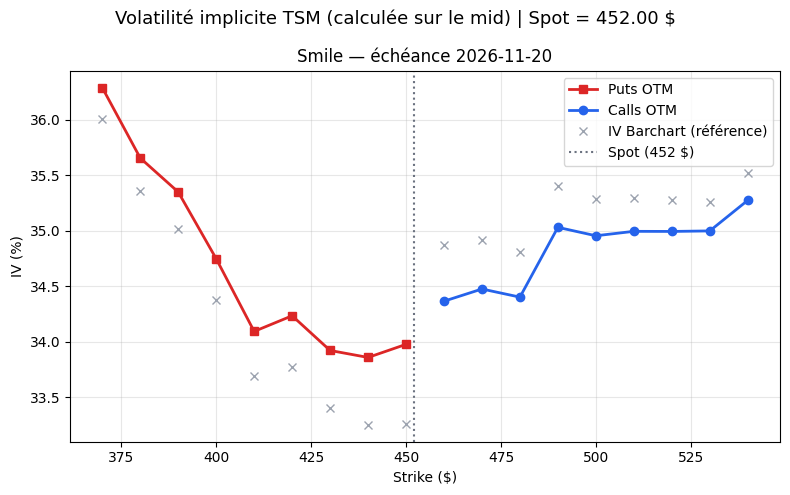

In [6]:
def atm_iv(exp):
    """IV ATM = moyenne de l'IV du call et du put au strike le plus proche du spot, calculées sur le mid."""
    T_e = max(days_to(exp), 1) / 365.0
    c_, p_ = get_chain(exp)
    out = []
    for df, ot in [(c_, "call"), (p_, "put")]:
        df = df[(df["bid"] > 0) & (df["ask"] > 0)]
        if df.empty: continue
        row = df.loc[(df["strike"] - S).abs().idxmin()]
        out.append(implied_vol((row["bid"] + row["ask"]) / 2, S, row["strike"], r, q, T_e, ot))
    out = [v for v in out if np.isfinite(v)]
    return (T_e, np.mean(out)) if out else (T_e, np.nan)

term = pd.DataFrame([atm_iv(e) for e in expirations if 7 <= days_to(e) <= 365], columns=["T", "iv_atm"]).dropna()
if len(term) < 2: print("Structure par terme : saisir au moins 2 échéances dans le CSV pour la tracer.")

show_term = len(term) >= 2
fig, axes = plt.subplots(1, 2 if show_term else 1, figsize=(14 if show_term else 8, 5))
axes = np.atleast_1d(axes)
fig.suptitle(f"Volatilité implicite {TICKER} (calculée sur le mid) | Spot = {S:.2f} $", fontsize=13)

ax = axes[0]
for ot, col, mk in [("put", "#DC2626", "s"), ("call", "#2563EB", "o")]:
    d = smile[smile["type"] == ot]
    ax.plot(d["strike"], d["iv_mid"] * 100, mk + "-", color=col, lw=2, ms=6, label=f"{ot.capitalize()}s OTM")
if smile["iv_yahoo"].notna().any():
    ax.plot(smile["strike"], smile["iv_yahoo"] * 100, "x", color="#9CA3AF", label=f"{IV_LABEL} (référence)")
ax.axvline(S, color="#6B7280", ls=":", lw=1.5, label=f"Spot ({S:.0f} $)")
ax.set_xlabel("Strike ($)"); ax.set_ylabel("IV (%)"); ax.set_title(f"Smile — échéance {exp_date}")
ax.legend(); ax.grid(alpha=0.3)

if show_term:
  ax = axes[1]
  ax.plot(term["T"] * 12, term["iv_atm"] * 100, "o-", color="#7C3AED", lw=2, ms=6)
  ax.set_xlabel("Maturité (mois)"); ax.set_ylabel("IV ATM (%)"); ax.set_title("Structure par terme")
  ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Résumé chiffré

Les chiffres à utiliser dans la conclusion et sur le CV. Le skew est mesuré comme l'écart d'IV entre un strike à 90 % du spot (put OTM) et l'ATM, et entre 110 % du spot (call OTM) et l'ATM.

In [7]:
def iv_at(k_ratio):
    return float(np.interp(k_ratio * S, smile["strike"], smile["iv_mid"]))

iv_atm_exp = iv_at(1.00)
iv_90, iv_110 = iv_at(0.90), iv_at(1.10)
if SOURCE == "csv":
    vol_hist = VOL_HIST_MANUAL
else:
    hist = yf.Ticker(TICKER).history(period="1y")["Close"]
    vol_hist = float(np.log(hist).diff().std() * np.sqrt(252))

print(f"Source                    : {SOURCE_LABEL} ({today:%d/%m/%Y})")
print(f"Échéance analysée         : {exp_date} ({days_to(exp_date)} jours)")
print(f"IV ATM                    : {iv_atm_exp:.1%}")
print(f"IV put 90 % du spot       : {iv_90:.1%}   → skew put  = {(iv_90 - iv_atm_exp) * 100:+.1f} pts de vol")
print(f"IV call 110 % du spot     : {iv_110:.1%}   → skew call = {(iv_110 - iv_atm_exp) * 100:+.1f} pts de vol")
if np.isfinite(vol_hist):
    print(f"Vol historique            : {vol_hist:.1%}")
    print(f"Prime de vol (IV − hist.) : {(iv_atm_exp - vol_hist) * 100:+.1f} pts")
if len(term) >= 2:
    print(f"Structure par terme       : IV ATM de {term['iv_atm'].iloc[0]:.1%} ({term['T'].iloc[0]*12:.1f} mois) "
          f"à {term['iv_atm'].iloc[-1]:.1%} ({term['T'].iloc[-1]*12:.1f} mois)")

Source                    : Barchart, clôture du 22/09/2026 (22/09/2026)
Échéance analysée         : 2026-11-20 (59 jours)
IV ATM                    : 34.1%
IV put 90 % du spot       : 34.3%   → skew put  = +0.2 pts de vol
IV call 110 % du spot     : 35.0%   → skew call = +0.9 pts de vol
Vol historique            : 27.8%
Prime de vol (IV − hist.) : +6.2 pts


## 8. Conclusions — snapshot du 22/09/2026 (clôture, échéance 20/11/2026, 59 jours)

### Niveau de volatilité
- **IV ATM : 34,1 %**, pour une vol historique de **27,8 %**. Le marché price donc **~6 points de vol de plus** que ce qui s'est réalisé.
- Cette prime s'explique en partie par les **résultats trimestriels du 15/10/2026**, qui tombent pendant la vie de l'option : le marché intègre le risque d'un fort mouvement le jour de l'annonce.
- En relatif, la vol reste **basse** : Barchart indique un IV Rank de 6,5 % (proche du plus bas sur un an, après un pic à 56 % en juillet).

### Forme du smile
- **Côté puts** : l'IV est quasi plate jusqu'à 90 % du spot (+0,2 pt), puis remonte nettement dans la queue : **36,3 % au strike 370** (82 % du spot), soit **+2,2 pts** au-dessus de l'ATM. La protection contre un krach (risque géopolitique Taïwan-Chine, retournement du cycle des semi-conducteurs) se paie surtout sur les puts très OTM.
- **Côté calls** : l'IV **monte** avec le strike, jusqu'à **35,3 % au strike 540** (120 % du spot). Ce **call skew** est typique des valeurs liées à l'IA : les investisseurs achètent des calls OTM pour s'exposer à une forte hausse.
- Au total, le smile est **relativement plat** (moins de 3 pts d'écart sur ±20 % de strike), avec les deux ailes légèrement relevées.

### Validation
- **Solveur** : reprice exact des prix mid (écart < 10⁻⁸ $). Mes IV sont à **0,4 pt de vol** en médiane de celles de Barchart ; l'écart vient des hypothèses de taux, de dividende et du modèle (Barchart tient compte de l'exercice anticipé).
- **Parité call-put sur les prix de marché** : écart moyen de **0,07 % du spot** près de la monnaie, ce qui valide la cohérence des données et des paramètres (r = 4,09 %, q = 0 car le prochain détachement du 10/12 tombe après l'échéance).

### Limites
- Black-Scholes suppose une **vol constante** : le smile observé montre que ce n'est pas le cas.
- Les options TSM sont **américaines**, alors que BS price des options européennes. L'impact est faible ici (pas de dividende avant l'échéance), mais explique les petits écarts de parité sur les strikes dans la monnaie.

### Qualité des données
Une première version de ce projet utilisait l'IV fournie par Yahoo Finance, récupérée **hors séance** : bid et ask étaient à 0 et les vols implicites inexploitables (3 à 12 %). D'où le choix de **recalculer l'IV sur le mid avec mes propres solveurs**, et de figer un snapshot daté et sourcé pour rendre l'analyse reproductible.

### Perspectives
Ajouter une 2ᵉ échéance **avant** les résultats du 15/10 pour isoler la prime liée à l'annonce ; tester un modèle à volatilité stochastique (Heston, SABR) pour reproduire le smile.